In [1]:
import numpy as np
import pandas as pd
import numpy.linalg as linalg
import matplotlib.pyplot as plt

We have an augmented data matrix $X$ where each row of $X$ is a sample with each column representing a feature with a 1 entry in the first column for the bias and true value vector $y$ where the ith entry $y$ is the true value for the ith sample. When using column normalised data, ensure that when regressing on new data, this is normalised using the column mean and standard deviations of the training data.

Our prediction using linear regression is then $y_{pred}=XW$, where $W$ is a weights vector with first entry the bias term.

For ordinary least squares, we have the loss function $f(W)=(y-XW)^T(y-XW)$, which is the residual sum of squares (RSS). For the linear regression problem, we aim to minimise the loss function. We can do this by finding the $W$ which minimises the loss using matrix calculus.
$$
\begin{gathered}
    v=y-XW
    \\
    f(W)=(y-XW)^T(y-XW)=v^Tv=g(v)
    \\
    dg=(\frac{\partial g}{\partial v})^Tdv=(2v)^Tdv
    \\
    dv=\frac{\partial v}{\partial W}dW=-XdW
    \\
    dg=(2v)^T\frac{\partial v}{\partial W}dW
\end{gathered}
$$
As $f(W)$ is a convex equation in $W$, the $W$ where the grad is zero will result in the global minimum for the loss.
$$
\begin{gathered}
    \frac{\partial g}{\partial W}=(2v)^T(-X)=2(y-XW)^T(-X)=0 
    \\ \implies y^TX-(XW)^TX=0 \implies X^Ty=X^TXW \implies W=(X^TX)^{-1}X^Ty
\end{gathered}
$$

where $\frac{\partial v}{\partial W}$ is the jacobian and $dv$ and $dg$ are the vector of component wise differentials.
$X^TX$ only has an inverse when full rank, hence, if there is any sort of colinearity in the data there won't be a unique solution.

So our prediction using the least squares solution will be $y_{pred}=X(X^TX)^{-1}X^Ty$ using the original training data. This is the projection of the vector y onto the columnspace of X (so there difference is orthogonal to columnspace). Geometrically, the closest point $y_{pred}$ to $y$, whilst lying on the subspace of $X$ is such that their difference is orthogonal to the subspace. This is the same as their difference being orthogonal to all columns of $X$, i.e. $X^T(y_{pred}-y)=0$ which was one of the intermediate steps in acquiring our solution. So the geometry of this solution also agrees with the analytical solution.

In [2]:
#Closed Form Linear Regression
def LinRegExact(X,y):
    """Linear regression using closed form analytical solution"""
    mat=np.dot(linalg.inv(np.dot(X.transpose(),X)),X.transpose())
    beta=np.dot(mat,y)
    return beta

In the below gradient descent we have used the grad of the loss function from before. Rather than directly computing the solution we use an iterative method. Intuitively we can think about this as using the grad to see how close we are to the global minimum; as we get closer to the global minimum, the grad will get closer to 0 hence we need to 'nudge' our parameters less to get closer to the minimum.

Iteration and learning rate are chosen such that we converge to the solution fairly quickly. The chosen optimisation hyperparameters depend on the data and model used.

In [3]:
#Grad desc. Linear Regression Normalised

def LinRegGradDesc(X,y,learningRate=0.05,iterations=5000):
    """Linear regression using gradient descent"""
    test=np.zeros(np.shape(X[1]))
    Grad= lambda test: -2*X.T@(y-X@test)
    RSS= lambda test: (y-X@test).T@(y-X@test)
    rss=np.zeros(iterations)
    for i in range(iterations):
        test-= 1/np.shape(X)[0]*Grad(test)*learningRate
        rss[i]=RSS(test)
    return test,rss

I highlighted earlier that if $X^TX$ is not full rank we would not get a unique solution. Another problem that arises from this is that if columns of $X^TX$ are closely aligned (e.g. two features are highly correlated), the 2 columns may be very close to being linearly dependent hence reducing rank, the solution will not generalise well as $X^TX$ will then be ill-conditioned, small changes in the input data may cause large changes in the inverse of $X^TX$ hence large variation in the prediction.

A work around for this is ridge regression. We use the loss function $(y-XW)^T(y-XW)+\lambda W^TW$. $X$ is the same as before, however, y must be centered around 0 otherwise we will penalise the bias term. This is again a convex function and using the same procedure as before we can deduce that $W=(X^TX+\lambda I)^{-1}X^T(y-\bar{y})$ using matrix calculus.

Using cross-validation we can show that the variance in each of the parameters is lower using ridge regression than the previous least squares method. We can also use cross-validation to determine the $\lambda$ which minimises the root mean square error on the training data.

In [4]:
#Ridge Regression

def RidgeReg(A,y,lam=50):
    """Analytical solution for ridge regression. Input matrix A should have 1s column and have normalised data by columns.
    lam is the ridge parameter for penalisaton"""
    ymean=np.mean(y)
    betaR=linalg.solve(A.T@A+lam*np.identity(np.shape(A)[1]), A.T@(y-np.mean(y)))
    return betaR,ymean

def kfold_indices(n, k):
    """Outputs a partition of n into k parts"""
    index = np.random.permutation(n)
    return np.array_split(index, k)

def cross_validation(X, y, k=5, method='OLS',lamb=0):
    """k-fold cross validation. I partition all the input samples into k folds. 
    I train the models k times using k-1 folds to train and the last unused fold to test.
    This is used to see how the models might generalise without having to find new test data."""
    if method=='OLS':
        folds = kfold_indices(np.shape(X)[0], k)
        rmses = []
        for i in range(k):
            test_index = folds[i]
            train_index = np.hstack([folds[j] for j in range(k) if j != i])
            X_train, y_train = X[train_index], y[train_index]
            X_test, y_test = X[test_index], y[test_index]
            beta = LinRegExact(X_train, y_train)
            preds = X_test@beta
            rmse = np.sqrt(np.mean((preds - y_test)**2))
            rmses.append(rmse)
    elif method=='Ridge':
        #X should not have a 1s column
        folds = kfold_indices(np.shape(X)[0], k)
        rmses = []
        for i in range(k):
            test_index = folds[i]
            train_index = np.hstack([folds[j] for j in range(k) if j != i])
            X_train, y_train = X[train_index], y[train_index]
            X_test, y_test = X[test_index], y[test_index]
            beta,ymean = RidgeReg(X_train, y_train,lam=lamb)
            preds = X_test@beta+ymean
            rmse = np.sqrt(np.mean((preds - y_test)**2))
            rmses.append(rmse)
    else:
        print('Invalid method')
        return
    return np.mean(rmses), np.std(rmses)


In [5]:
#Data preparation (adding 1s columns, coding gender and normalising data)

abaloneData=pd.read_csv('abalone.data.csv')
abaloneData['gender']=abaloneData['gender'].map({'M':1, 'I':0, 'F':-1}) #code genders into numbers
rings=np.array(abaloneData['Rings'])
originaldata=np.array(abaloneData.drop('Rings',axis=1))
mu=np.mean(originaldata,axis=0)
sigma=np.std(originaldata,axis=0)
data=originaldata.copy()
data[:,1:]=(originaldata[:,1:]-mu[1:])/sigma[1:]
X=np.column_stack((np.ones(np.shape(data)[0]),data))
corrmat=np.corrcoef(data,rowvar=False)

In [6]:
#Finding 'optimal' lambda
folds=250
maxlam=50
lambdas=[maxlam*i/folds for i in range(1,folds+1)]
rmses=[]
for l in lambdas:
    rmses.append(cross_validation(X,rings,folds,'Ridge',l)[0])
index=rmses.index(min(rmses))
bestlam=lambdas[index]
print(bestlam)

0.6


In [7]:
#Coefficients
LSExact=LinRegExact(X,rings)
LSGD,trainingRSS=LinRegGradDesc(X,rings)
Ridge,ymean=RidgeReg(X,rings,lam=bestlam)

1.969575707015842 2.254338718784555 
 1.9687650353694373 2.254407051332636 
 1.9686551893335318 2.254367679390184
[ 9.9861582   0.07152394 -0.23372708  1.4066588   0.44608184  4.68721192
 -4.67343062 -1.02404654  1.24105867] 
 [ 9.9861759   0.07117044 -0.23542683  1.40673885  0.44598392  4.50128303
 -4.59300812 -0.98029259  1.31024719] 
 [-3.53752737e-03  7.11181340e-02 -2.26296595e-01  1.39755640e+00
  4.46658668e-01  4.56925889e+00 -4.61806950e+00 -9.97480450e-01
  1.28184255e+00]


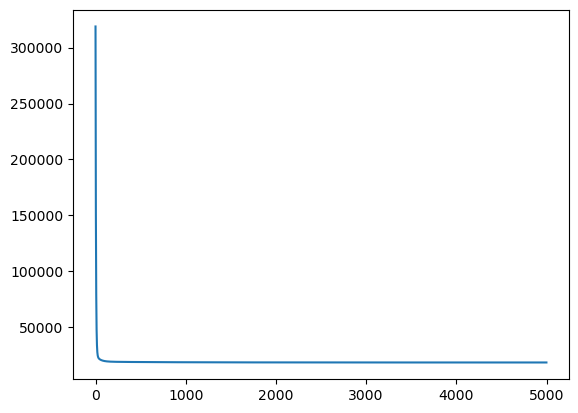

In [8]:
def RMSE(prediction,actual):
    MSE=np.mean((prediction-actual)**2)
    RMSE=np.sqrt(MSE)
    return RMSE

testData=pd.read_csv('testdata.csv')
testData['gender']=testData['gender'].map({'M':1, 'I':0, 'F':-1})
testArray=np.array(testData.drop('Rings',axis=1))
testRings=np.array(testData['Rings'])
normalisedArray=np.column_stack((np.ones(np.shape(testArray)[0]),(testArray-mu)/sigma))

exactPrediction=normalisedArray@LSExact
gdPrediction=normalisedArray@LSGD
ridgePrediction=normalisedArray@Ridge+ymean
exactRMSE=RMSE(exactPrediction,testRings)
GDRMSE=RMSE(gdPrediction,testRings)
RidgeRMSE=RMSE(ridgePrediction,testRings)
trainingRMSEexact=RMSE(X@LSExact,rings)
trainingRMSEgd=RMSE(X@LSGD,rings)
trainingRMSEridge=RMSE(X@Ridge+ymean,rings)
print(exactRMSE,trainingRMSEexact, "\n", GDRMSE,trainingRMSEgd, "\n",RidgeRMSE,trainingRMSEridge)
print(LSExact,"\n",LSGD,"\n",Ridge)
plt.plot(range(5000),trainingRSS)

We can see all 3 of my implementations have similar RMSE for the test data so they all seem to have generalised similarly in this case.

When looking directly at the coefficients we can see both least squares implementations have similar coefficients showing that GD has converged successfully (roughly). The curve supports this as we can see the loss has decreased massively.

In [9]:
#Bootstrapping to see variance of non-bias coefficients in Ridge Regression and Least Squares

def Bootstrap(X,y,iterations):
    samples=np.shape(X)[0]
    Y=np.column_stack((np.ones(samples),X))
    coefmat1=np.zeros((iterations,np.shape(X)[1]))
    coefmat2=np.zeros((iterations,np.shape(X)[1]))
    for i in range(iterations):
        rowchoices=np.random.choice(samples,samples,replace=True)
        coefmat1[i]=LinRegExact(Y[rowchoices],y[rowchoices])[1:]
        coefmat2[i]=RidgeReg(Y[rowchoices],y[rowchoices])[0][1:]
    var1=np.var(coefmat1,axis=0)
    var2=np.var(coefmat2,axis=0)
    mean1=np.mean(coefmat1,axis=0)
    mean2=np.mean(coefmat2,axis=0)
    return var1, var2, mean1, mean2

print(Bootstrap(data,rings,1000)[0:2])

(array([0.00247131, 0.07053421, 0.0877288 , 0.07632488, 0.42867366,
       0.11124945, 0.04496117, 0.08332254]), array([0.00242584, 0.01827572, 0.02631187, 0.07752147, 0.03287247,
       0.01814687, 0.0161554 , 0.02698815]))


Each entry of the arrays is the variance in the bootstrap procedure of the coefficient of the ith feature input. We can clealry see that in all cases Ridge regression has reduced the variance which is as we expected and hoped.

In [10]:
#CV to observe mean RMSE between Ridge Regression and Least Squares

OLSMeanRMSE=cross_validation(X,rings,20,'OLS')[0]
RidgeMeanRMSE=cross_validation(data,rings,20,'Ridge')[0]
print(OLSMeanRMSE,RidgeMeanRMSE)

2.2803283859030206 2.2752327104327215


Ridge regression here has a very similar mean RMSE so it has a similar accuracy to least squares on average. Hence we have shown that ridge regression can achieve similar accuracy as least squares but has more stable results shown by the lower variance in coefficients.